# Pós-hoc: onde o modelo erra

Três perguntas com consequências distintas:

1. Quais classes concentram o erro?
2. O erro é do dado ou do treino?
3. O erro correlaciona com propriedade da imagem?

In [1]:
RAIZ <- "../../results/_smoke"
RUN <- "latest"

suppressMessages(devtools::load_all("../../analysis", quiet = TRUE))
suppressMessages({
  library(ggplot2)
  library(dplyr)
})
options(repr.plot.width = 9, repr.plot.height = 4.5)

run <- read_run(RUN, RAIZ)
m <- run$manifest
sel <- m$selected_arm
seed_sel <- if (sel == "tuned") m$mcnemar_tuned_seed else m$mcnemar_baseline_seed
cat(sprintf("run %s | arm %s | seed de melhor validação %s\n", run$run_id, sel, seed_sel))

run cnn-medmnist-2026-08-18_14-08-34 | arm tuned | seed de melhor validação 43


## 1. Erro por classe

In [2]:
pc <- run$predictions |>
  filter(arm == sel, split == "test", seed_init == seed_sel)
per_class_metrics(pc$y_true, pc$y_pred, m$class_names) |>
  arrange(recall) |>
  as.data.frame()

class_idx,class_name,support,precision,recall,f1
<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>
0,malignant,42,0.2222222,0.04761905,0.07843137
1,"normal, benign",114,0.7278912,0.93859649,0.81992337


In [3]:
# Recall com IC binomial: em classe rara o recall é estimado sobre poucas dezenas
# de exemplos, e reportá-lo sem intervalo sugere precisão que o dado não sustenta.
per_class_metrics(pc$y_true, pc$y_pred, m$class_names) |>
  filter(support > 0) |>
  rowwise() |>
  mutate(
    ci = {
      ci <- prop.test(round(recall * support), support)$conf.int
      sprintf("[%.0f%%, %.0f%%]", 100 * ci[1], 100 * ci[2])
    }
  ) |>
  ungroup() |>
  select(class_name, support, recall, ci) |>
  as.data.frame()

class_name,support,recall,ci
<chr>,<int>,<dbl>,<chr>
malignant,42,0.04761905,"[1%, 17%]"
"normal, benign",114,0.93859649,"[87%, 97%]"


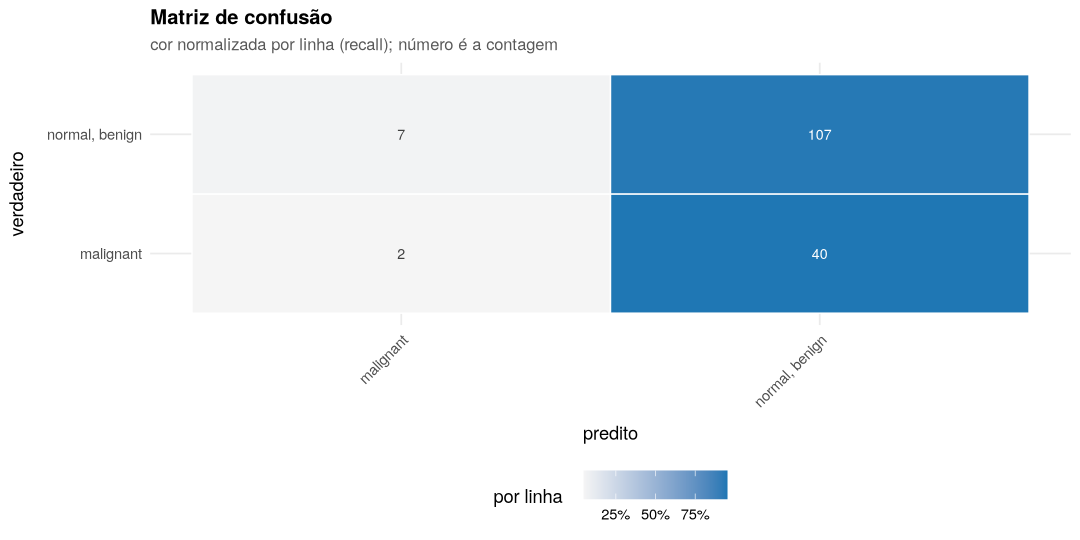

In [4]:
plot_confusion(confusion_matrix(pc$y_true, pc$y_pred, m$class_names))

In [5]:
pc |>
  filter(y_true != y_pred) |>
  count(y_true, y_pred, sort = TRUE) |>
  head(10) |>
  mutate(
    verdadeiro = m$class_names[y_true + 1],
    predito = m$class_names[y_pred + 1]
  ) |>
  select(verdadeiro, predito, n) |>
  as.data.frame()

verdadeiro,predito,n
<chr>,<chr>,<int>
malignant,"normal, benign",40
"normal, benign",malignant,7


## 2. Dificuldade do dado ou instabilidade do treino?

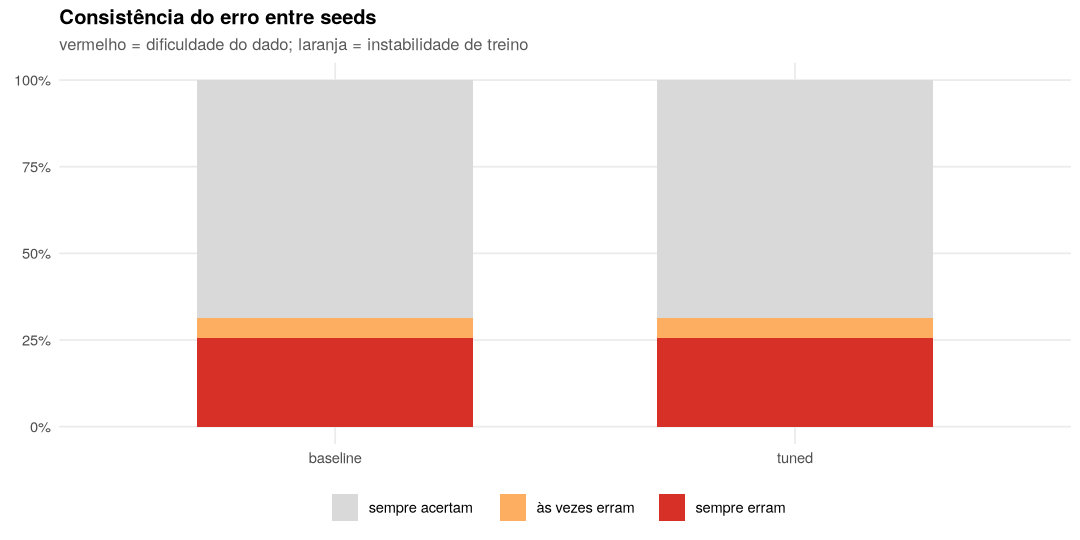

In [6]:
cw <- consistently_wrong(run, "test")
plot_error_consistency(cw)

In [7]:
cw |>
  group_by(arm) |>
  summarise(
    n_exemplos = n(),
    sempre_erram = sum(always_wrong),
    as_vezes = sum(sometimes_wrong),
    sempre_acertam = sum(n_wrong == 0),
    .groups = "drop"
  ) |>
  as.data.frame()

arm,n_exemplos,sempre_erram,as_vezes,sempre_acertam
<chr>,<int>,<int>,<int>,<int>
baseline,156,40,9,107
tuned,156,40,9,107


In [8]:
r <- cw |> filter(arm == sel)
cat(sprintf("sempre errados: %d (%.1f%% do teste)\n",
            sum(r$always_wrong), 100 * mean(r$always_wrong)))
cat(sprintf("às vezes errados: %d (%.1f%%)\n",
            sum(r$sometimes_wrong), 100 * mean(r$sometimes_wrong)))
cat("\nOs primeiros não melhoram com mais seeds nem outra inicialização.\n")
cat("Os segundos encolhem com treino mais estável: mais épocas, LR melhor, scheduler.\n")

sempre errados: 40 (25.6% do teste)


às vezes errados: 9 (5.8%)



Os primeiros não melhoram com mais seeds nem outra inicialização.


Os segundos encolhem com treino mais estável: mais épocas, LR melhor, scheduler.


In [9]:
# Os sempre-errados se concentram em alguma classe?
r |>
  filter(always_wrong) |>
  count(y_true) |>
  mutate(classe = m$class_names[y_true + 1]) |>
  select(classe, n) |>
  arrange(desc(n)) |>
  as.data.frame()

classe,n
<chr>,<int>
malignant,40


## 3. Os dois arms erram nos mesmos lugares?

In [10]:
wide <- run$predictions |>
  filter(split == "test", seed_init %in% c(m$mcnemar_baseline_seed, m$mcnemar_tuned_seed)) |>
  filter((arm == "baseline" & seed_init == m$mcnemar_baseline_seed) |
    (arm == "tuned" & seed_init == m$mcnemar_tuned_seed)) |>
  select(arm, example_idx, y_true, y_pred) |>
  tidyr::pivot_wider(names_from = arm, values_from = y_pred)

tab <- wide |>
  summarise(
    ambos_certos = sum(baseline == y_true & tuned == y_true),
    so_baseline = sum(baseline == y_true & tuned != y_true),
    so_tuned = sum(baseline != y_true & tuned == y_true),
    ambos_errados = sum(baseline != y_true & tuned != y_true)
  )
as.data.frame(tab)

ambos_certos,so_baseline,so_tuned,ambos_errados
<int>,<int>,<int>,<int>
109,0,0,47


In [11]:
mc <- mcnemar_from_run(run)
cat(sprintf("McNemar: n01 = %d, n10 = %d, %s, p = %.4e\n", mc$n01, mc$n10, mc$method, mc$p_value))
cat(sprintf("concordância: %.1f%% dos exemplos\n",
            100 * mean(wide$baseline == wide$tuned)))

McNemar: n01 = 0, n10 = 0, binom_exact, p = 1.0000e+00


concordância: 100.0% dos exemplos


## 4. O erro correlaciona com a imagem?

In [12]:
eda_dir <- file.path(results_root(RAIZ), "datasets", m$dataset_id)
tem_eda <- dir.exists(eda_dir)
if (!tem_eda) {
  cat(sprintf("EDA de '%s' ausente. Rode `just eda` para habilitar esta seção.\n", m$dataset_id))
}

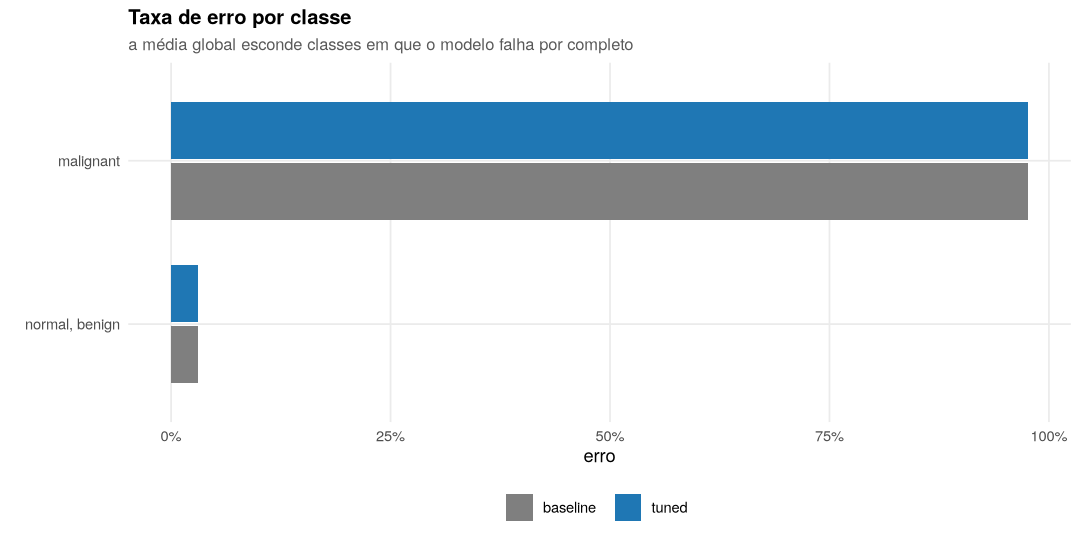

In [13]:
if (tem_eda) {
  joined <- join_predictions_eda(run, root = RAIZ)
  print(plot_error_by_class(joined, "test"))
}

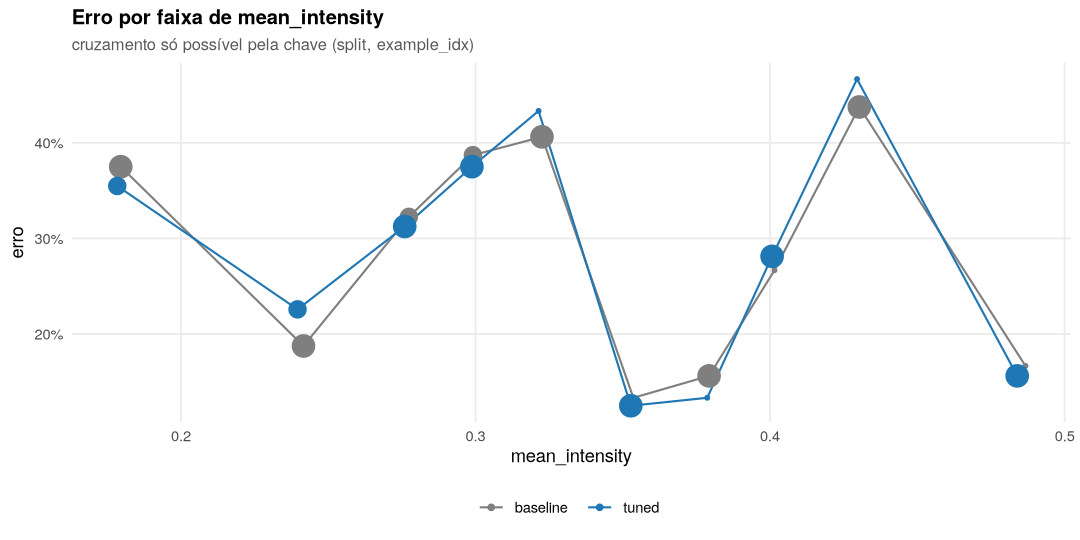

In [14]:
if (tem_eda) print(plot_error_vs_feature(joined, "mean_intensity", "test"))

In [15]:
if (tem_eda) {
  dificeis <- filter(cw, arm == sel, always_wrong)$example_idx
  joined |>
    filter(split == "test", arm == sel) |>
    distinct(example_idx, mean_intensity, std_intensity, nonzero_frac) |>
    mutate(grupo = ifelse(example_idx %in% dificeis, "sempre errado", "resto")) |>
    group_by(grupo) |>
    summarise(n = n(), across(c(mean_intensity, std_intensity, nonzero_frac), mean), .groups = "drop") |>
    as.data.frame()
}

grupo,n,mean_intensity,std_intensity,nonzero_frac
<chr>,<int>,<dbl>,<dbl>,<dbl>
resto,116,0.3429135,0.1753141,0.9996371
sempre errado,40,0.3159217,0.1893273,1.0000000


## Confiança nos erros

In [16]:
if (!is.null(run$probabilities)) {
  ct <- confidence_table(run, sel, "test")
  ct |>
    group_by(correct) |>
    summarise(n = n(), confianca_media = mean(confidence), .groups = "drop") |>
    as.data.frame()
}

correct,n,confianca_media
<lgl>,<int>,<dbl>
FALSE,47,0.5037172
TRUE,109,0.5037431


In [17]:
if (!is.null(run$probabilities)) {
  cat("Erros com maior confiança (os mais preocupantes):\n")
  ct |>
    filter(!correct) |>
    arrange(desc(confidence)) |>
    head(8) |>
    mutate(
      verdadeiro = m$class_names[y_true + 1],
      predito = m$class_names[y_pred + 1],
      confianca = sprintf("%.1f%%", 100 * confidence)
    ) |>
    select(example_idx, verdadeiro, predito, confianca) |>
    as.data.frame()
}

Erros com maior confiança (os mais preocupantes):


example_idx,verdadeiro,predito,confianca
<dbl>,<chr>,<chr>,<chr>
48,malignant,"normal, benign",50.8%
107,malignant,"normal, benign",50.8%
85,malignant,"normal, benign",50.7%
6,malignant,"normal, benign",50.7%
40,malignant,"normal, benign",50.7%
106,malignant,"normal, benign",50.6%
0,malignant,"normal, benign",50.6%
55,malignant,"normal, benign",50.6%


Erro com alta confiança é pior que erro com baixa: um modelo que hesita onde erra
ainda é utilizável com limiar; um que erra com certeza não é. Esses `example_idx`
são os candidatos naturais para inspeção visual, que é a próxima capacidade a
acrescentar no export.